In [7]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient

client = GridStatusClient(api_key="b66c2e64755c44eb9be56667d66a18f6")
QUERY_LIMIT = 10000

TZ = "America/New_York"

# Define the intended NYISO-local window
pt_start = pd.Timestamp("2025-09-28 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-09-29 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT = client.get_dataset(
    dataset= "nyiso_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "CAPITL",
)

df_DA = client.get_dataset(
    dataset= "nyiso_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "CAPITL",
)

T = 24                  # hours
K = 12                  # 5-minute steps per hour
NK = T*K
t0 = 14                 # initial hour of day
k0 = t0 * K             # initial 5-minute interval of day

# Align price dictionaries to absolute index sets
# =========================
t_keys = list(range(t0, t0 + T))          # 14..37 (inclusive)
k_keys = list(range(k0, k0 + NK))         # 168..455 (inclusive)

# 1) DA prices: map 0-based rows -> absolute hours 14..37
lmp_DA = {t_keys[i]: float(df_DA.loc[i, "lmp"]) for i in range(T)}

# 2) RT 5-min prices: map 0-based rows -> absolute sub-steps 168..455
lmp_RT = {k_keys[i]: float(df_RT.loc[i, "lmp"]) for i in range(NK)}

# 3) Hourly RT averages over contiguous 12×5-min windows
lt_RTE = {}
for i, t in enumerate(t_keys):
    s = i * K
    e = (i + 1) * K
    lt_RTE[t] = float(df_RT.loc[s:e - 1, "lmp"].mean())


# Build model
model = ConcreteModel()

# Sets
model.IDX_i = Set(initialize=['EV1', 'EV2', 'EV3', 'EV4', 'EV5'])
model.IDX_t = RangeSet(t0, t0 + T - 1)           # 14..37
model.IDX_k = RangeSet(k0, k0 + NK - 1)          # 168..455
model.IDX_w = Set(initialize=['w1'])             # single scenario

# Parameters
model.Dt     = Param(initialize=1/12)  # 5 minutes in hours
model.prob_w = Param(initialize=1.0)

# LMP Prices
model.l_DAE  = Param(model.IDX_t, initialize=lmp_DA)   # $/MWh
model.lk_RTE = Param(model.IDX_k, initialize=lmp_RT)   # $/MWh
model.lt_RTE = Param(model.IDX_t, initialize=lt_RTE)   # $/MWh

# EV fleet parameters
model.E_bat_max = Param(model.IDX_i, initialize={'EV1': 20, 'EV2': 20, 'EV3': 20, 'EV4': 20, 'EV5': 20})  # kWh
model.n         = Param(model.IDX_i, initialize={'EV1': 0.9, 'EV2': 0.9, 'EV3': 0.9, 'EV4': 0.9, 'EV5': 0.9})
model.Pchrg     = Param(model.IDX_i, initialize={'EV1': 3, 'EV2': 3, 'EV3': 3, 'EV4': 3, 'EV5': 3})       # kW
model.SOEa      = Param(model.IDX_i, initialize={'EV1': 0.2, 'EV2': 0.1, 'EV3': 0.3, 'EV4': 0.4, 'EV5': 0.2})
model.SOEd      = Param(model.IDX_i, initialize={'EV1': 0.95, 'EV2': 0.95, 'EV3': 0.95, 'EV4': 0.95, 'EV5': 0.95})
model.SOEcc_cv  = Param(initialize=0.85) 

# Availability windows (hours counted from 14:00 of the first day;)
Ta_hr = {'EV1': 17, 'EV2': 18, 'EV3': 19, 'EV4': 19, 'EV5': 18}  # plug-in hour
Td_hr = {'EV1': 31, 'EV2': 31, 'EV3': 32, 'EV4': 31, 'EV5': 30}  # unplug hour

# Convert to absolute sub-steps (no extra shift needed)
Ta_k = {i: Ta_hr[i] * K for i in Ta_hr}
Td_k = {i: Td_hr[i] * K for i in Td_hr}

def u_init(model, i, k):
    return 1 if (k >= Ta_k[i] and k < Td_k[i]) else 0

model.u = Param(model.IDX_i, model.IDX_k, initialize=u_init, within=Binary)

# Penalty settings
dev = 0.3
max_gap = max(0.0, max(lt_RTE[t] - lmp_DA[t] for t in t_keys))
M_fixed = 1.01 / (1.0 - dev) * max_gap
model.M   = Param(initialize= M_fixed)   # $/MWh

# Decision variables
model.E_DA       = Var(model.IDX_t, within=NonNegativeReals)                        # MWh
model.E_RT       = Var(model.IDX_k, model.IDX_w, within=NonNegativeReals)           # MWh (agg over EVs)
model.E_i_RT     = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)  # kWh
model.SOE        = Var(model.IDX_i, model.IDX_k, model.IDX_w, bounds=(0, 1))        # fraction
model.P_RT_max   = Var(model.IDX_i, model.IDX_k, model.IDX_w, within=NonNegativeReals)  # kW

model.DE         = Var(model.IDX_t, model.IDX_w)  # signed deviation (MWh) # aux
model.DE_U_Up    = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.DE_U_Down  = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_Up   = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.Pnlty_Down = Var(model.IDX_t, model.IDX_w, within=NonNegativeReals)
model.b = Var(model.IDX_t, model.IDX_w, within=Binary)

# Constraints

def DE_constraint(model, t, w):
    k0_t, k1_t = t * K, (t + 1) * K
    return model.DE[t, w] == model.E_DA[t] - sum(model.E_RT[k, w] for k in range(k0_t, k1_t))
model.DEcon = Constraint(model.IDX_t, model.IDX_w, rule=DE_constraint)

model.DE3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.DE[t, w] == m.DE_U_Up[t, w] - m.DE_U_Down[t, w])

# Activate only one side depending on b
def de_up_limit(m, t, w):
    # DEup can be positive only if b=1
    return m.DE_U_Up[t, w] <= 10**6 * m.b[t, w]
model.de_up_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_up_limit)

def de_dn_limit(m, t, w):
    # DEdn can be positive only if b=0
    return m.DE_U_Down[t, w] <= 10**6 * (1 - m.b[t, w])
model.de_dn_limit = Constraint(model.IDX_t, model.IDX_w, rule=de_dn_limit)

# Enforce DE sign consistency:
def de_pos_enforce(m, t, w):
    # If b=1 → DE >= 0
    return m.DE[t, w] >= -10**6 * (1 - m.b[t, w])
model.de_pos_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_pos_enforce)

def de_neg_enforce(m, t, w):
    # If b=0 → DE <= 0
    return m.DE[t, w] <= 10**6 * m.b[t, w]
model.de_neg_enforce = Constraint(model.IDX_t, model.IDX_w, rule=de_neg_enforce)

model.EVcon = Constraint(
    model.IDX_k, model.IDX_w,
    rule=lambda m, k, w: m.E_RT[k, w] == sum(m.E_i_RT[i, k, w] for i in m.IDX_i) / 1000.0
)

model.EV2con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.E_i_RT[i, k, w] <= m.P_RT_max[i, k, w] * m.Dt
)

model.EV3con = Constraint(
    model.IDX_i, model.IDX_k, model.IDX_w,
    rule=lambda m, i, k, w: m.P_RT_max[i, k, w] <= m.u[i, k] * m.Pchrg[i]
)

def EV4_rule(model, i, k, w):
    return model.P_RT_max[i, k, w] <= model.u[i, k] * model.Pchrg[i] * ((1 - model.SOE[i, k, w]) / (1 - model.SOEcc_cv))
model.EV4con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV4_rule)

def SOE_init_k0(model, i, w):
    return model.SOE[i, k0, w] == model.SOEa[i]
model.SOE_init_k0 = Constraint(model.IDX_i, model.IDX_w, rule=SOE_init_k0)

def EV5_rule(model, i, k, w):
    if k == k0 + NK - 1:
        return Constraint.Skip
    return model.SOE[i, k + 1, w] == model.SOE[i, k, w] + (model.n[i] / model.E_bat_max[i]) * model.E_i_RT[i, k, w]
model.EV5con = Constraint(model.IDX_i, model.IDX_k, model.IDX_w, rule=EV5_rule)

def EV6_rule(model, i, w):
    k_dep = Td_k[i] - 1
    if k0 <= k_dep < k0 + NK:
        return model.SOE[i, k_dep, w] == model.SOEd[i]
    return Constraint.Skip
model.EV6con = Constraint(model.IDX_i, model.IDX_w, rule=EV6_rule)

model.Pcon  = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_Up[t, w]   >= 0)
model.P3con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_Down[t, w] >= 0)
model.P2con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_Up[t, w]   >= m.M * (m.DE_U_Up[t, w]   - dev * m.E_DA[t]))
model.P4con = Constraint(model.IDX_t, model.IDX_w, rule=lambda m, t, w: m.Pnlty_Down[t, w] >= m.M * (m.DE_U_Down[t, w] - dev * m.E_DA[t]))

# Objective (maximize settlement value)
def objFunc_(model):
    w = 'w1'
    return sum(
        model.l_DAE[t] * model.E_DA[t]
        - model.lt_RTE[t] * model.DE[t, w]
        + model.Pnlty_Up[t, w] + model.Pnlty_Down[t, w]
        for t in model.IDX_t
    )
model.cost = Objective(rule=objFunc_, sense=minimize)

# =========================
# Solve
# =========================
solver = SolverFactory('glpk')
model.dual = Suffix(direction=Suffix.IMPORT)
results = solver.solve(model, tee=False)

print(results.solver.status, results.solver.termination_condition)
print(f"Total Cost: ${value(model.cost):.2f}")

# =========================
# Light result peek
# =========================
# Show a few hourly DA awards and deviations
da_series = pd.Series({t: value(model.E_DA[t]) for t in model.IDX_t}, name="E_DA_MWh")
de_series = pd.Series({t: value(model.DE[t, 'w1']) for t in model.IDX_t}, name="DE_MWh")
prices_da = pd.Series({t: value(model.l_DAE[t]) for t in model.IDX_t}, name="DA_$perMWh")
prices_rt = pd.Series({t: value(model.lt_RTE[t]) for t in model.IDX_t}, name="RTavg_$perMWh")
out = pd.concat([prices_da, prices_rt, da_series, de_series], axis=1)
print(out.head(8).round(3))


2025-11-11 19:12:43 - INFO - Fetching Page 1...
2025-11-11 19:12:43 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_lmp_real_time_5_min/query
2025-11-11 19:12:43 - INFO - Params: {'start_time': Timestamp('2025-09-28 18:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-09-29 18:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': 'CAPITL', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2025-11-11 19:12:44 - INFO - Done in 0.52 seconds. 
2025-11-11 19:12:44 - INFO - Total number of rows: 293
2025-11-11 19:12:44 - INFO - Fetching Page 1...
2025-11-11 19:12:44 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_lmp_day_ahead_hourly/query
2025-11-11 19:12:44 - INFO - Params: {'start_time': Timestamp

ok optimal
Total Cost: $2.27
    DA_$perMWh  RTavg_$perMWh  E_DA_MWh  DE_MWh
14       37.03         38.488       0.0     0.0
15       41.99         40.605       0.0     0.0
16       46.80         40.344       0.0     0.0
17       61.05         56.551       0.0     0.0
18       66.70         90.046       0.0     0.0
19       66.80         80.867       0.0     0.0
20       52.77         45.706       0.0     0.0
21       47.66         36.684       0.0     0.0


In [4]:
df_DA

,interval_start_utc,interval_end_utc,market,location,location_type,lmp,energy,congestion,loss
0,2025-01-28 19:00:00+00:00,2025-01-28 20:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,116.61,87.61,24.18,4.82
1,2025-01-28 20:00:00+00:00,2025-01-28 21:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,137.90,88.16,44.63,5.11
2,2025-01-28 21:00:00+00:00,2025-01-28 22:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,169.33,88.26,75.60,5.47
3,2025-01-28 22:00:00+00:00,2025-01-28 23:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,212.02,168.17,33.25,10.60
4,2025-01-28 23:00:00+00:00,2025-01-29 00:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,200.00,170.57,18.68,10.75
5,2025-01-29 00:00:00+00:00,2025-01-29 01:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,210.54,116.12,87.22,7.20
6,2025-01-29 01:00:00+00:00,2025-01-29 02:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,200.75,140.78,51.52,8.45
7,2025-01-29 02:00:00+00:00,2025-01-29 03:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,147.59,104.18,37.26,6.15
8,2025-01-29 03:00:00+00:00,2025-01-29 04:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,131.65,87.54,38.86,5.25
9,2025-01-29 04:00:00+00:00,2025-01-29 05:00:00+00:00,DAY_AHEAD_HOURLY,CAPITL,Zone,129.29,87.17,37.15,4.97


In [5]:
df_RT

,interval_start_utc,interval_end_utc,market,location,location_type,lmp,energy,congestion,loss
0,2025-01-28 19:00:00+00:00,2025-01-28 19:05:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,58.73,42.94,13.47,2.32
1,2025-01-28 19:05:00+00:00,2025-01-28 19:10:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,58.73,42.94,13.47,2.32
2,2025-01-28 19:10:00+00:00,2025-01-28 19:15:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,55.45,52.56,-0.00,2.89
3,2025-01-28 19:15:00+00:00,2025-01-28 19:20:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,55.84,43.83,9.64,2.37
4,2025-01-28 19:20:00+00:00,2025-01-28 19:25:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,57.28,43.55,11.38,2.35
...,...,...,...,...,...,...,...,...,...
312,2025-01-29 18:45:00+00:00,2025-01-29 18:50:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,162.24,154.66,-0.00,7.58
313,2025-01-29 18:50:00+00:00,2025-01-29 18:55:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,162.40,154.67,-0.00,7.73
314,2025-01-29 18:55:00+00:00,2025-01-29 19:00:00+00:00,REAL_TIME_5_MIN,CAPITL,Zone,148.79,141.44,-0.00,7.35
315,2025-01-29 18:57:36+00:00,2025-01-29 19:02:36+00:00,REAL_TIME_5_MIN,CAPITL,Zone,99.31,94.05,-0.00,5.26


In [4]:
import numpy as np
import pandas as pd

# ---- Helpers ----
def top_bottom_spread(values: np.ndarray, n: int) -> float:
    """Sum of top-n minus sum of bottom-n."""
    if len(values) < n:
        return np.nan
    s = np.sort(values)
    return float(s[-n:].sum() - s[:n].sum())

def percentiles(series: pd.Series, ps=(50,70,90)) -> dict:
    s = series.dropna().values
    if s.size == 0:
        return {f"P{p}": np.nan for p in ps}
    return {f"P{p}": float(np.percentile(s, p)) for p in ps}

def rtb_concentration_days(series: pd.Series, threshold=0.30) -> int:
    """Min #days to reach `threshold` of total RTB120 (over the given window)."""
    s = series.dropna().sort_values(ascending=False).values
    if s.size == 0:
        return 0
    csum = np.cumsum(s)
    target = threshold * csum[-1]
    return int(np.searchsorted(csum, target, side="left") + 1)

def _hist_mode(values: np.ndarray, bins=50) -> float:
    if values.size == 0:
        return np.nan
    counts, edges = np.histogram(values, bins=bins)
    i = counts.argmax()
    return float((edges[i] + edges[i+1]) / 2)

def rtb_distortion(series: pd.Series) -> float:
    """mean / mode of daily RTB120."""
    v = series.dropna().values
    if v.size == 0:
        return np.nan
    m = _hist_mode(v)
    return float(np.mean(v) / m) if m not in (0, np.nan) and not np.isnan(m) else np.nan

# ---- Make sure your frames have a UTC DatetimeIndex ----
def set_dt_index(df: pd.DataFrame, candidates=("interval_start_utc", "Interval Start")) -> pd.DataFrame:
    for c in candidates:
        if c in df.columns:
            ts = pd.to_datetime(df[c], utc=True)
            return df.set_index(ts)
    raise KeyError(f"None of the datetime columns {candidates} found in df: {df.columns.tolist()}")

df_DA = set_dt_index(df_DA)
df_RT = set_dt_index(df_RT)

# ---- Metrics (grouped by UTC calendar day) ----
# DA TB(2h): top 2 hourly minus bottom 2 hourly per day (UTC)
DA_TB_2h_by_day = df_DA["lmp"].groupby(df_DA["lmp"].index.date)\
    .apply(lambda s: top_bottom_spread(s.values, 2))\
    .rename("DA_TB_2h")

# RT TB(2h): build hourly from 5-min, then top 2 minus bottom 2 per day (UTC)
RT_TB_2h_by_day = df_RT["lmp"].groupby(df_RT["lmp"].index.date)\
    .apply(lambda s: top_bottom_spread(s.values, 2))\
    .rename("RT_TB_2h")

RTB120_by_day = df_RT["lmp"].groupby(df_RT["lmp"].index.date)\
    .apply(lambda s: top_bottom_spread(s.values, 24))\
    .rename("RTB120")

# ---- P-values ----
DA_TB_2h_percentiles  = percentiles(DA_TB_2h_by_day, ps=(50,70,90))
RT_TB_2h_percentiles  = percentiles(RT_TB_2h_by_day, ps=(50,70,90))
RTB120_percentiles    = percentiles(RTB120_by_day,   ps=(50,70,90))

# ---- Concentration & Distortion on RTB120 ----
RTB_Concentration_30pct_days   = rtb_concentration_days(RTB120_by_day, threshold=0.30)
RTB_Distortion_mean_over_mode  = rtb_distortion(RTB120_by_day)

# ---- Print compact summary ----
summary = {
    "DA_TB_2h_by_day": DA_TB_2h_by_day.round(3).to_dict(),
    "RT_TB_2h_by_day": RT_TB_2h_by_day.round(3).to_dict(),
    "RTB120_by_day":   RTB120_by_day.round(3).to_dict(),
    "DA_TB_2h_percentiles": {k: None if np.isnan(v) else round(v,3) for k,v in DA_TB_2h_percentiles.items()},
    "RT_TB_2h_percentiles": {k: None if np.isnan(v) else round(v,3) for k,v in RT_TB_2h_percentiles.items()},
    "RTB120_percentiles":   {k: None if np.isnan(v) else round(v,3) for k,v in RTB120_percentiles.items()},
    "RTB_Concentration_30pct_days": int(RTB_Concentration_30pct_days),
    "RTB_Distortion_mean_over_mode": None if np.isnan(RTB_Distortion_mean_over_mode) else round(RTB_Distortion_mean_over_mode,3),
}
print(pd.Series(summary, dtype="object"))

DA_TB_2h_by_day                             {2025-09-28: 54.48, 2025-09-29: 45.03}
RT_TB_2h_by_day                            {2025-09-28: 136.27, 2025-09-29: 95.03}
RTB120_by_day                            {2025-09-28: 1196.98, 2025-09-29: 589.49}
DA_TB_2h_percentiles                 {'P50': 49.755, 'P70': 51.645, 'P90': 53.535}
RT_TB_2h_percentiles               {'P50': 115.65, 'P70': 123.898, 'P90': 132.146}
RTB120_percentiles               {'P50': 893.235, 'P70': 1014.733, 'P90': 1136....
RTB_Concentration_30pct_days                                                     1
RTB_Distortion_mean_over_mode                                                  1.5
dtype: object


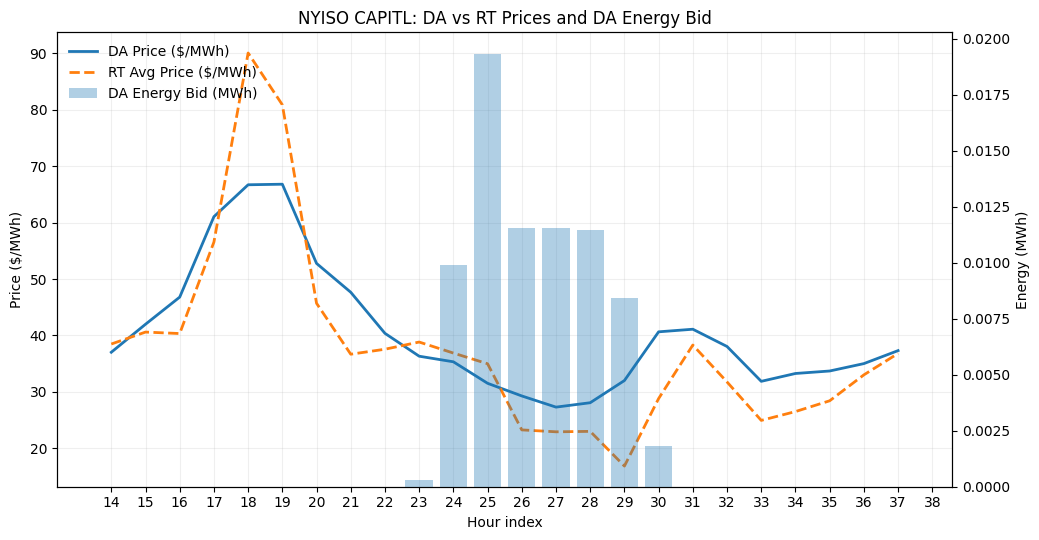

In [11]:
import matplotlib.pyplot as plt

# ---- Build aligned x and series ----
hours = sorted(list(model.IDX_t))                 # [14..37]
da_price = [float(value(model.l_DAE[t])) for t in hours]
rt_price = [float(value(model.lt_RTE[t])) for t in hours]
e_da     = [float(value(model.E_DA[t])) for t in hours]

# ---- Plot ----
fig, ax1 = plt.subplots(figsize=(10.5, 5.5))

# Prices on left y-axis
p1, = ax1.plot(hours, da_price, linewidth=2, label="DA Price ($/MWh)")
p2, = ax1.plot(hours, rt_price, linewidth=2, linestyle="--", label="RT Avg Price ($/MWh)")
ax1.set_xlabel("Hour index")
ax1.set_ylabel("Price ($/MWh)")
ax1.grid(True, which="both", axis="both", alpha=0.2)

# Energy on right y-axis
ax2 = ax1.twinx()
b = ax2.bar(hours, e_da, alpha=0.35, width=0.8, label="DA Energy Bid (MWh)")
ax2.set_ylabel("Energy (MWh)")

# X ticks 14..38 (include 38 as a tick for readability)
ax1.set_xticks(list(range(14, 39)))

# Unified legend
handles = [p1, p2, b]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="upper left", frameon=False)

plt.title("NYISO CAPITL: DA vs RT Prices and DA Energy Bid")
plt.tight_layout()
plt.show()

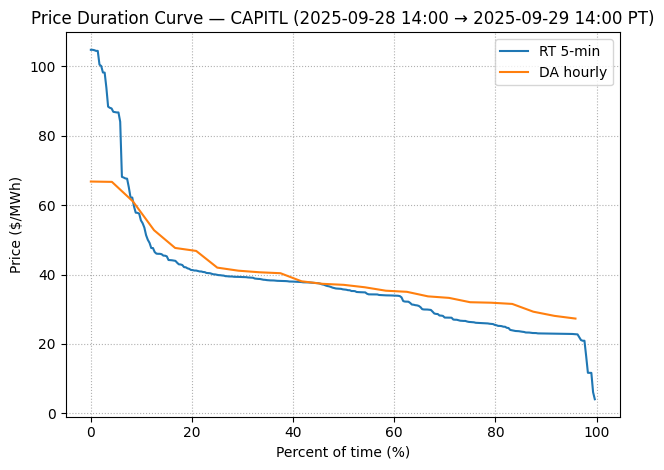

In [8]:
# ---------- Price Duration Curve (PDC) ----------
import numpy as np
import matplotlib.pyplot as plt

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra="CAPITL (2025-09-28 14:00 → 2025-09-29 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt[price_col])
    s_da = _sorted_desc(df_da[price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT, df_DA)

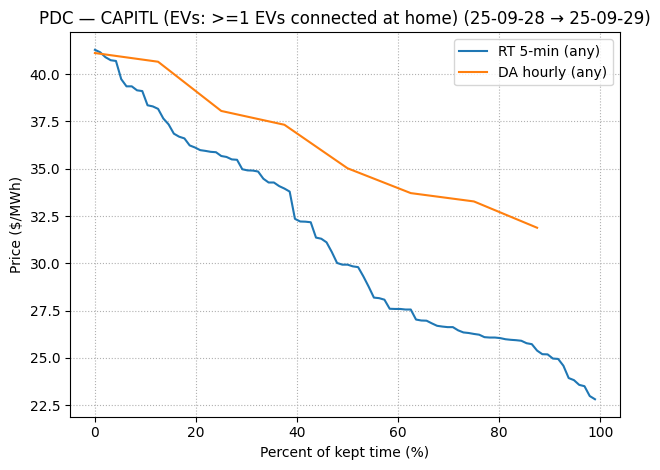

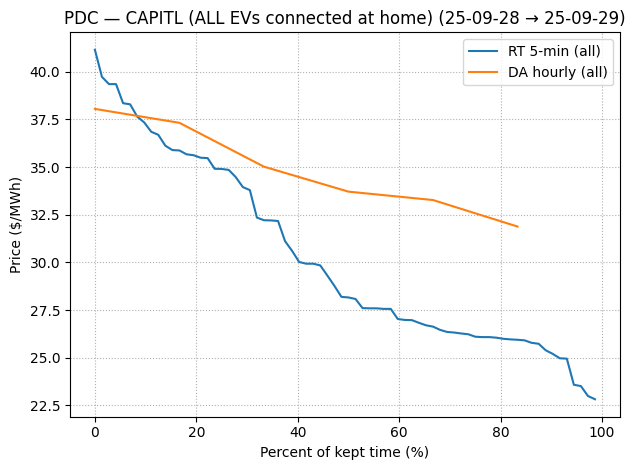

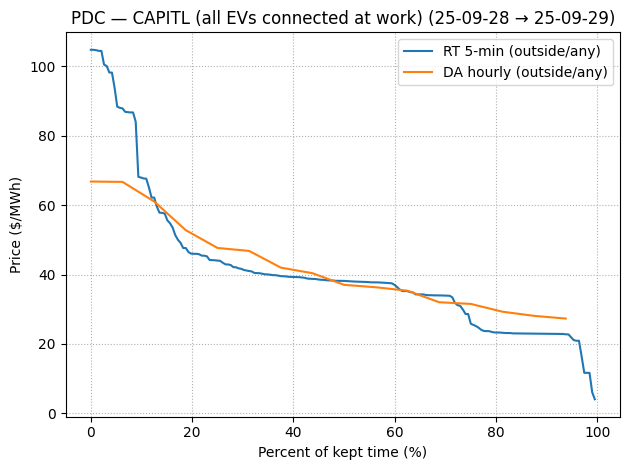

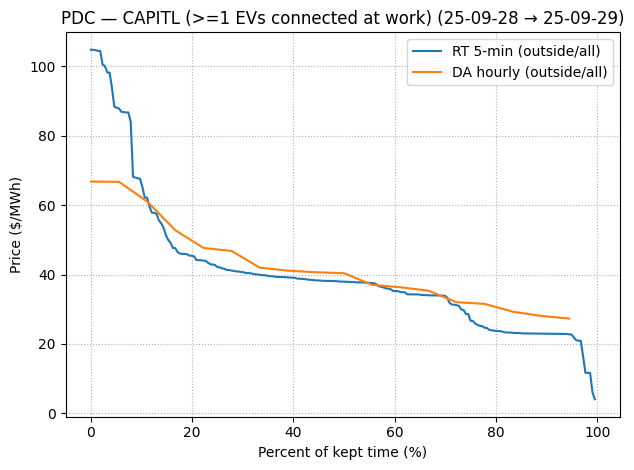

In [10]:
# ---------- PDC limited to plug-in windows ----------
import numpy as np
import matplotlib.pyplot as plt

def _sorted_desc(values):
    s = pd.Series(values, dtype=float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def _sanitize_lengths(df_rt, df_da, NK, T, time_col_rt="interval_start_utc", time_col_da="interval_start_utc"):
    # Optional but recommended: sort, drop dupes, and trim to exactly NK / T rows
    if time_col_rt in df_rt.columns:
        df_rt = (df_rt.assign(_t=pd.to_datetime(df_rt[time_col_rt], utc=True))
                       .sort_values("_t")
                       .drop_duplicates(subset=["_t","location"], keep="last"))
    if time_col_da in df_da.columns:
        df_da = (df_da.assign(_t=pd.to_datetime(df_da[time_col_da], utc=True))
                       .sort_values("_t")
                       .drop_duplicates(subset=["_t","location"], keep="last"))
    return df_rt.iloc[:NK].copy(), df_da.iloc[:T].copy()

def _build_availability_masks(Ta_hr, Td_hr, T, K):
    NK = T * K
    # Per-5min arrays (relative to your model's 0-based substep indices)
    mask_any = np.zeros(NK, dtype=bool)
    weights  = np.zeros(NK, dtype=int)

    # Start with all-True, then AND per-EV windows to get "all" mask
    mask_all = np.ones(NK, dtype=bool)

    for ev in Ta_hr:
        s = Ta_hr[ev] * K
        e = Td_hr[ev] * K
        this = np.zeros(NK, dtype=bool)
        this[s:e] = True
        mask_any |= this
        mask_all &= this
        weights[s:e] += 1  # count #EVs available per 5-min step

    # Aggregate to hourly masks
    mask_da_any = np.array([mask_any[h*K:(h+1)*K].any() for h in range(T)], dtype=bool)
    mask_da_all = np.array([mask_all[h*K:(h+1)*K].all() for h in range(T)], dtype=bool)
    # Hourly weights = sum of per-5min EV-counts within the hour
    weights_da   = np.array([weights[h*K:(h+1)*K].sum() for h in range(T)], dtype=int)

    return mask_any, mask_all, weights, mask_da_any, mask_da_all, weights_da

def plot_pdc_available(df_rt, df_da, price_col="lmp",
                       title_extra="(plug-in windows only)",
                       mode="any"):
    """
    mode: "any" (union), "all" (intersection), "weighted" (repeat values by #EVs available)
    """
    # Ensure clean lengths (288 RT rows, 24 DA rows)
    _rt, _da = _sanitize_lengths(df_rt, df_da, NK, T)

    # Build availability masks from your Ta_hr/Td_hr
    mask_rt_any, mask_rt_all, w_rt, mask_da_any, mask_da_all, w_da = _build_availability_masks(Ta_hr, Td_hr, T, K)

    rt_vals_full = _rt[price_col].to_numpy().astype(float)
    da_vals_full = _da[price_col].to_numpy().astype(float)

    if mode == "any":
        rt_vals = rt_vals_full[mask_rt_any]
        da_vals = da_vals_full[mask_da_any]
    elif mode == "all":
        rt_vals = rt_vals_full[mask_rt_all]
        da_vals = da_vals_full[mask_da_all]
    elif mode == "weighted":
        # Repeat each timestep by the number of EVs available then build PDC
        rt_vals = np.repeat(rt_vals_full[mask_rt_any], w_rt[mask_rt_any])
        da_vals = np.repeat(da_vals_full[mask_da_any],  w_da[mask_da_any])
    else:
        raise ValueError("mode must be 'any', 'all', or 'weighted'")

    # Sorted (high -> low)
    s_rt = _sorted_desc(rt_vals)
    s_da = _sorted_desc(da_vals)

    # X axis as percent of kept time (not whole day)
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False) if len(s_rt) else np.array([])
    x_da = np.linspace(0, 100, len(s_da), endpoint=False) if len(s_da) else np.array([])

    plt.figure()
    if len(s_rt):
        plt.plot(x_rt, s_rt.values, label=f"RT 5-min ({mode})")
    if len(s_da):
        plt.plot(x_da, s_da.values, label=f"DA hourly ({mode})")
    plt.xlabel("Percent of kept time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"PDC — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# ---- Usage examples ----
# Union of EV plug-in windows:
plot_pdc_available(
    df_RT,
    df_DA,
    title_extra="CAPITL (EVs: >=1 EVs connected at home) (25-09-28 → 25-09-29)",
    mode="any"
)

# Intersection (all EVs simultaneously connected):
plot_pdc_available(
     df_RT,
     df_DA,
     title_extra="CAPITL (ALL EVs connected at home) (25-09-28 → 25-09-29)",
     mode="all"
 )
# ---------- PDC limited to NON plug-in windows (outside Ta–Td) ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Ta_hr = {'EV1': 16, 'EV2': 17, 'EV3': 18, 'EV4': 18, 'EV5': 17}  # plug-in hour
Td_hr = {'EV1': 32, 'EV2': 32, 'EV3': 33, 'EV4': 32, 'EV5': 31}  # unplug hour

def _sorted_desc(values):
    s = pd.Series(values, dtype=float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def _sanitize_lengths(df_rt, df_da, NK, T, time_col_rt="interval_start_utc", time_col_da="interval_start_utc"):
    # Optional but recommended: sort, drop dupes, and trim to exactly NK / T rows
    if time_col_rt in df_rt.columns:
        df_rt = (df_rt.assign(_t=pd.to_datetime(df_rt[time_col_rt], utc=True))
                       .sort_values("_t")
                       .drop_duplicates(subset=["_t","location"], keep="last"))
    if time_col_da in df_da.columns:
        df_da = (df_da.assign(_t=pd.to_datetime(df_da[time_col_da], utc=True))
                       .sort_values("_t")
                       .drop_duplicates(subset=["_t","location"], keep="last"))
    return df_rt.iloc[:NK].copy(), df_da.iloc[:T].copy()

def _build_availability_masks(Ta_hr, Td_hr, T, K):
    NK = T * K
    # Per-5min arrays (relative to your model's 0-based substep indices)
    mask_any = np.zeros(NK, dtype=bool)   # union of all EV plug-in windows
    weights  = np.zeros(NK, dtype=int)    # #EVs available per 5-min step
    mask_all = np.ones(NK, dtype=bool)    # intersection of all EV plug-in windows

    for ev in Ta_hr:
        s = Ta_hr[ev] * K
        e = Td_hr[ev] * K
        this = np.zeros(NK, dtype=bool)
        this[s:e] = True
        mask_any |= this
        mask_all &= this
        weights[s:e] += 1

    # Aggregate to hourly masks
    mask_da_any = np.array([mask_any[h*K:(h+1)*K].any() for h in range(T)], dtype=bool)
    mask_da_all = np.array([mask_all[h*K:(h+1)*K].all() for h in range(T)], dtype=bool)
    weights_da  = np.array([weights[h*K:(h+1)*K].sum() for h in range(T)], dtype=int)

    return mask_any, mask_all, weights, mask_da_any, mask_da_all, weights_da

def plot_pdc_available(
    df_rt, df_da, price_col="lmp",
    title_extra="(outside plug-in windows)",
    mode="any",
    window="outside"  # "inside" (default behavior before) or "outside"
):
    """
    mode: "any" (union), "all" (intersection), "weighted" (repeat values by #EVs available)
    window: "inside" (within Ta–Td) or "outside" (complement of Ta–Td)
    Note: 'weighted' only makes sense for window="inside".
    """
    # Expect globals: T, K, NK, Ta_hr, Td_hr
    _rt, _da = _sanitize_lengths(df_rt, df_da, NK, T)

    mask_rt_any, mask_rt_all, w_rt, mask_da_any, mask_da_all, w_da = _build_availability_masks(Ta_hr, Td_hr, T, K)

    # Choose inside vs outside masks
    if window == "inside":
        m_rt_any, m_rt_all = mask_rt_any, mask_rt_all
        m_da_any, m_da_all = mask_da_any, mask_da_all
        w_da_use, w_rt_use = w_da, w_rt
    elif window == "outside":
        m_rt_any, m_rt_all = ~mask_rt_any, ~mask_rt_all
        m_da_any, m_da_all = ~mask_da_any, ~mask_da_all
        # weights don’t apply outside (no EVs connected), so set to ones for safe indexing
        w_da_use = np.ones_like(w_da)
        w_rt_use = np.ones_like(w_rt)
        if mode == "weighted":
            raise ValueError("mode='weighted' is not meaningful for window='outside'. Use 'any' or 'all'.")
    else:
        raise ValueError("window must be 'inside' or 'outside'")

    rt_vals_full = _rt[price_col].to_numpy().astype(float)
    da_vals_full = _da[price_col].to_numpy().astype(float)

    if mode == "any":
        rt_vals = rt_vals_full[m_rt_any]
        da_vals = da_vals_full[m_da_any]
    elif mode == "all":
        rt_vals = rt_vals_full[m_rt_all]
        da_vals = da_vals_full[m_da_all]
    elif mode == "weighted":
        # Only valid for window="inside"
        rt_vals = np.repeat(rt_vals_full[m_rt_any], w_rt_use[m_rt_any])
        da_vals = np.repeat(da_vals_full[m_da_any],  w_da_use[m_da_any])
    else:
        raise ValueError("mode must be 'any', 'all', or 'weighted'")

    s_rt = _sorted_desc(rt_vals)
    s_da = _sorted_desc(da_vals)

    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False) if len(s_rt) else np.array([])
    x_da = np.linspace(0, 100, len(s_da), endpoint=False) if len(s_da) else np.array([])

    plt.figure()
    if len(s_rt):
        plt.plot(x_rt, s_rt.values, label=f"RT 5-min ({window}/{mode})")
    if len(s_da):
        plt.plot(x_da, s_da.values, label=f"DA hourly ({window}/{mode})")
    plt.xlabel("Percent of kept time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"PDC — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# ---- Usage examples: OUTSIDE plug-in windows only ----
# Complement of union (times when NO EV is connected):
plot_pdc_available(
    df_RT,
    df_DA,
    title_extra="CAPITL (all EVs connected at work) (25-09-28 → 25-09-29)",
    mode="any",
    window="outside"
)

# Complement of intersection (times when NOT all EVs are connected simultaneously):
plot_pdc_available(
    df_RT,
    df_DA,
    title_extra="CAPITL (>=1 EVs connected at work) (25-09-28 → 25-09-29)",
    mode="all",
    window="outside"
)
